← [Reglas y hechos](03-sistema-experto-reglas.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Motor de inferencia](05-motor-de-inferencia.ipynb) →

# 04 · Factor de certeza



## Estado vigente del proyecto (actualizado el 13 de agosto de 2026)

Esta serie conserva explicaciones y resultados históricos, pero la referencia
operativa actual es la siguiente:

- El sistema experto tiene **193 reglas**, CF estilo MYCIN, meta-reglas,
  encadenamiento hacia adelante y hacia atrás. Su voto usa OpenAI como
  proveedor principal, con heurísticas OpenCV que refinan atributos.
- El modelo local que participa en la decisión es **MobileNetV2 TFLite
  float32**, corrida `run_20260721_2129`; clasifica solo `plastico | vidrio`.
  MobileNetV3-Large INT8 está archivado como respaldo y **no emite votos**.
- En 1.000 capturas OV3660/QVGA, V2 obtuvo **71,60 %** de exactitud y
  **71,25 %** de macro-F1; V3 INT8 obtuvo 57,10 % y 57,09 %. La validación
  histórica de 98,43 % no describe por sí sola el rendimiento del robot.
- La ESP32-CAM toma tres fotos: se suman los seis votos válidos de ambas
  fuentes. `desconocido` es abstención; un empate se resuelve con el proveedor.
  Si el proveedor se abstiene las tres veces, el modelo local necesita 3/3.

La documentación operativa es [`ia/vision-service/README.md`](../../ia/vision-service/README.md),
[`model/README.md`](../../ia/vision-service/model/README.md) y
[`PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md`](../../docs/PLAN-INTEGRACION-VISION-MAIN-2026-08-13.md).


## El problema que resuelve

Supón que tres reglas concluyen que el objeto es vidrio, con pesos 0,8 · 0,7 ·
0,6. ¿Cuál es la certeza total?

Las respuestas ingenuas fallan todas:

| Método | Resultado | Por qué está mal |
| --- | --- | --- |
| Sumar | 2,1 | No significa nada; supera el máximo |
| Promediar | 0,70 | Añadir una regla débil **baja** el total: absurdo, más evidencia no debería restar |
| Tomar el máximo | 0,80 | Las otras dos reglas no aportan nada: también absurdo |

Lo que se necesita es una operación donde cada evidencia adicional **suba** el
total, pero con rendimientos decrecientes, y sin llegar nunca a 1,0.



## La fórmula de MYCIN

Viene del sistema médico de Stanford de los años 70 y Reci la implementa tal
cual (`certainty_factor.py:31`):

```python
CF_combinado = CF1 + CF2 × (1 − CF1)
```

Se lee así: *la certeza que ya tenías, más una fracción de lo que te falta para
llegar a 1*. Cada nueva evidencia se lleva un pedazo del espacio restante, nunca
todo.

Con los tres valores del ejemplo:

```
paso 1:   0,8 + 0,7 × (1 − 0,8)  =  0,8 + 0,14  =  0,94
paso 2:   0,94 + 0,6 × (1 − 0,94) =  0,94 + 0,036 = 0,976
```

Tres reglas dan **0,976**. Sube con cada una, pero cada vez menos, y nunca
alcanza 1,0.



## Por qué esa forma

La propiedad clave: si `CF1 < 1` y `CF2 < 1`, entonces el resultado siempre es
`< 1`. **La certeza absoluta es inalcanzable por acumulación.**

Es una decisión epistemológica, no un truco de cálculo: ninguna cantidad de
evidencia indirecta debería producir certeza total. Encaja con la política
conservadora de Reci — si el sistema nunca puede estar absolutamente seguro,
siempre queda margen para abstenerse.

Compáralo con el defecto documentado de la red neuronal, que sí produce
`1.0000` sobre un mango. La softmax no tiene esta propiedad: reparte
probabilidad entre las clases disponibles y puede concentrarla toda en una.



Matplotlib is building the font cache; this may take a moment.


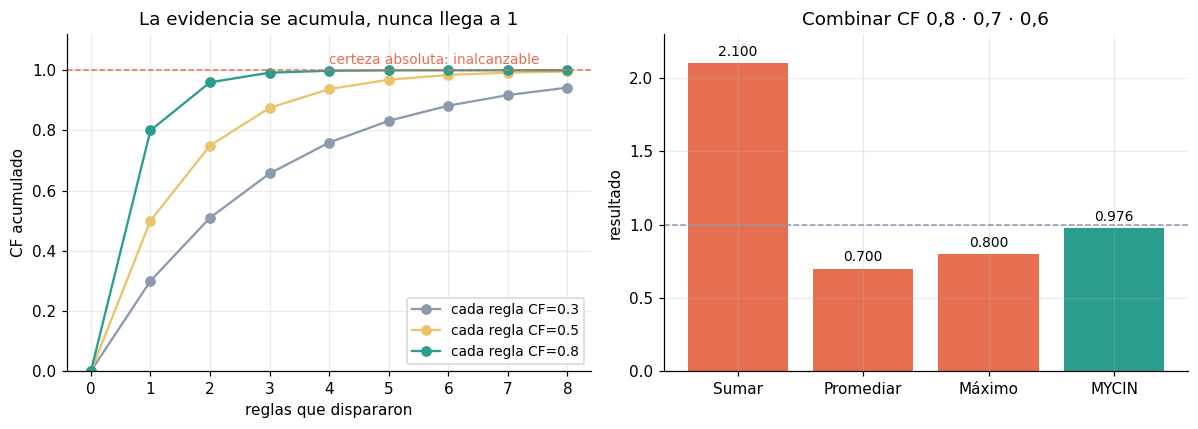

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

VIDRIO, PLASTICO, GRIS, ALERTA = "#2a9d8f", "#e9c46a", "#8d99ae", "#e76f51"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# Acumulación de evidencia con la fórmula de MYCIN
def combinar(cf1, cf2):
    return cf1 + cf2 * (1 - cf1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Izquierda: reglas iguales aplicadas una tras otra
for cf, color in [(0.3, GRIS), (0.5, PLASTICO), (0.8, VIDRIO)]:
    acumulado, serie = 0.0, [0.0]
    for _ in range(8):
        acumulado = combinar(acumulado, cf)
        serie.append(acumulado)
    ax1.plot(range(9), serie, "o-", color=color, label=f"cada regla CF={cf}")
ax1.axhline(1.0, ls="--", color=ALERTA, lw=1)
ax1.text(4, 1.02, "certeza absoluta: inalcanzable", color=ALERTA, fontsize=9)
ax1.set(xlabel="reglas que dispararon", ylabel="CF acumulado",
        title="La evidencia se acumula, nunca llega a 1", ylim=(0, 1.12))
ax1.legend(fontsize=9)

# Derecha: comparación con los métodos ingenuos
cfs = [0.8, 0.7, 0.6]
metodos = ["Sumar", "Promediar", "Máximo", "MYCIN"]
valores = [sum(cfs), np.mean(cfs), max(cfs), combinar(combinar(cfs[0], cfs[1]), cfs[2])]
colores = [ALERTA, ALERTA, ALERTA, VIDRIO]
barras = ax2.bar(metodos, valores, color=colores)
ax2.axhline(1.0, ls="--", color=GRIS, lw=1)
ax2.set(ylabel="resultado", title="Combinar CF 0,8 · 0,7 · 0,6", ylim=(0, 2.3))
for b, v in zip(barras, valores):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

## Los tres casos

La implementación cubre también evidencia en contra (`certainty_factor.py:39`):

```python
if cf1 >= 0 and cf2 >= 0:          # ambos a favor
    return cf1 + cf2 * (1 - cf1)
elif cf1 < 0 and cf2 < 0:          # ambos en contra
    return cf1 + cf2 * (1 + cf1)
else:                              # se contradicen
    return (cf1 + cf2) / (1 - min(abs(cf1), abs(cf2)))
```

El rango completo va de −1 a +1:

```
 +1,0  certeza positiva absoluta
  0,0  sin evidencia
 −1,0  certeza negativa absoluta (imposible)
```

El tercer caso —evidencia contradictoria— divide por `1 − min(|CF1|, |CF2|)`,
lo que **amplifica** el desacuerdo: si una regla dice 0,8 a favor y otra 0,7 en
contra, el resultado no es un tibio 0,1 sino 0,33. La contradicción se hace
visible en vez de cancelarse silenciosamente.

En la práctica Reci usa casi solo CF positivos: sus reglas aportan evidencia
**a favor** de una categoría, y la competencia entre categorías se resuelve
comparando sus CF acumulados.



## El umbral de apertura

El CF final no se usa solo para ordenar candidatos. Hay una línea dura
(`inference_engine.py`):

```python
UMBRAL_APERTURA_CF = 0.75   # CF mínimo para abrir compuerta
```

Por debajo de 0,75, el material gana la comparación pero **no abre nada**: el
resultado se degrada a `desconocido`. Es la política del documento
[01](01-el-problema.ipynb) expresada como número.

Vale la pena ver qué significa en términos de reglas. Una sola regla de 0,98
(un objeto reconocido con alta confianza) pasa el umbral por sí sola. Pero dos
reglas genéricas de 0,5 dan `0,5 + 0,5 × 0,5 = 0,75` — justo en el límite. Es
decir: **el sistema exige o una pista fuerte o varias medianas coincidentes**.



## Un CF no es una probabilidad

Es el malentendido más común y conviene fijarlo:

| | Probabilidad | Factor de certeza |
| --- | --- | --- |
| Suma sobre todas las hipótesis | Siempre 1,0 | No suma nada en particular |
| Origen | Frecuencias observadas | Juicio del experto |
| `P(A) = 0,7` implica | `P(no A) = 0,3` | Nada sobre `no A` |

Que el vidrio tenga CF 0,9 **no** implica que el plástico tenga 0,1. Las dos
hipótesis acumulan evidencia por separado y podrían tener ambas CF alto: eso
sería un conflicto que el motor debe resolver, no una imposibilidad aritmética.

Este punto importa cuando se comparan las salidas del sistema experto con las
de la red neuronal: el `0,95` de una y el `0,95` de la otra **no son la misma
magnitud** y no deberían promediarse. Es una de las razones por las que Reci
vota en vez de fusionar ([10](10-votacion-y-decision.ipynb)).

---

← [Reglas y hechos](03-sistema-experto-reglas.ipynb) · [Índice](00-indice.ipynb) · Siguiente: [Motor de inferencia](05-motor-de-inferencia.ipynb) →
